In [1]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ExpSineSquared, DotProduct
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel
from scipy.stats import norm
from skopt import gp_minimize
from skopt.space import Real
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import differential_evolution
from scipy.optimize import minimize

In [2]:
inputs3 = np.array([[0.17152521, 0.34391687, 0.2487372 ],
       [0.24211446, 0.64407427, 0.27243281],
       [0.53490572, 0.39850092, 0.17338873],
       [0.49258141, 0.61159319, 0.34017639],
       [0.13462167, 0.21991724, 0.45820622],
       [0.34552327, 0.94135983, 0.26936348],
       [0.15183663, 0.43999062, 0.99088187],
       [0.64550284, 0.39714294, 0.91977134],
       [0.74691195, 0.28419631, 0.22629985],
       [0.17047699, 0.6970324 , 0.14916943],
       [0.22054934, 0.29782524, 0.34355534],
       [0.66601366, 0.67198515, 0.2462953 ],
       [0.04680895, 0.23136024, 0.77061759],
       [0.60009728, 0.72513573, 0.06608864],
       [0.96599485, 0.86111969, 0.56682913],
       [0.415849, 0.683198, 0.044278],
       [0.437478, 0.528022, 0.555168],
       [0.397948, 0.386104, 0.477340],
       [0.404844, 0.434862, 0.463633]])

In [3]:
outputs3 = np.array([-0.1121222 , -0.08796286, -0.11141465, -0.03483531, -0.04800758,
       -0.11062091, -0.39892551, -0.11386851, -0.13146061, -0.09418956,
       -0.04694741, -0.10596504, -0.11804826, -0.03637783, -0.05675837, -0.05239372905933873,
       -0.021420880734232903, -0.0060146320761346505, -0.016621228164233726])

## Surrogate function

In [4]:
X = inputs3    # shape (15, 3)\n",
y = outputs3     # shape (15,)\n",

# Fit Gaussian Process surrogate
kernel1 = RBF(length_scale=1.5, length_scale_bounds=(1e-3, 1e2)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-9, 1e-1))

gp = GaussianProcessRegressor(
    kernel=kernel1,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42,
)

gp.fit(X, y)

print("Optimized kernel:", gp.kernel_)

Optimized kernel: RBF(length_scale=0.232) + WhiteKernel(noise_level=0.0143)


## Scatter plot - observations (3D)

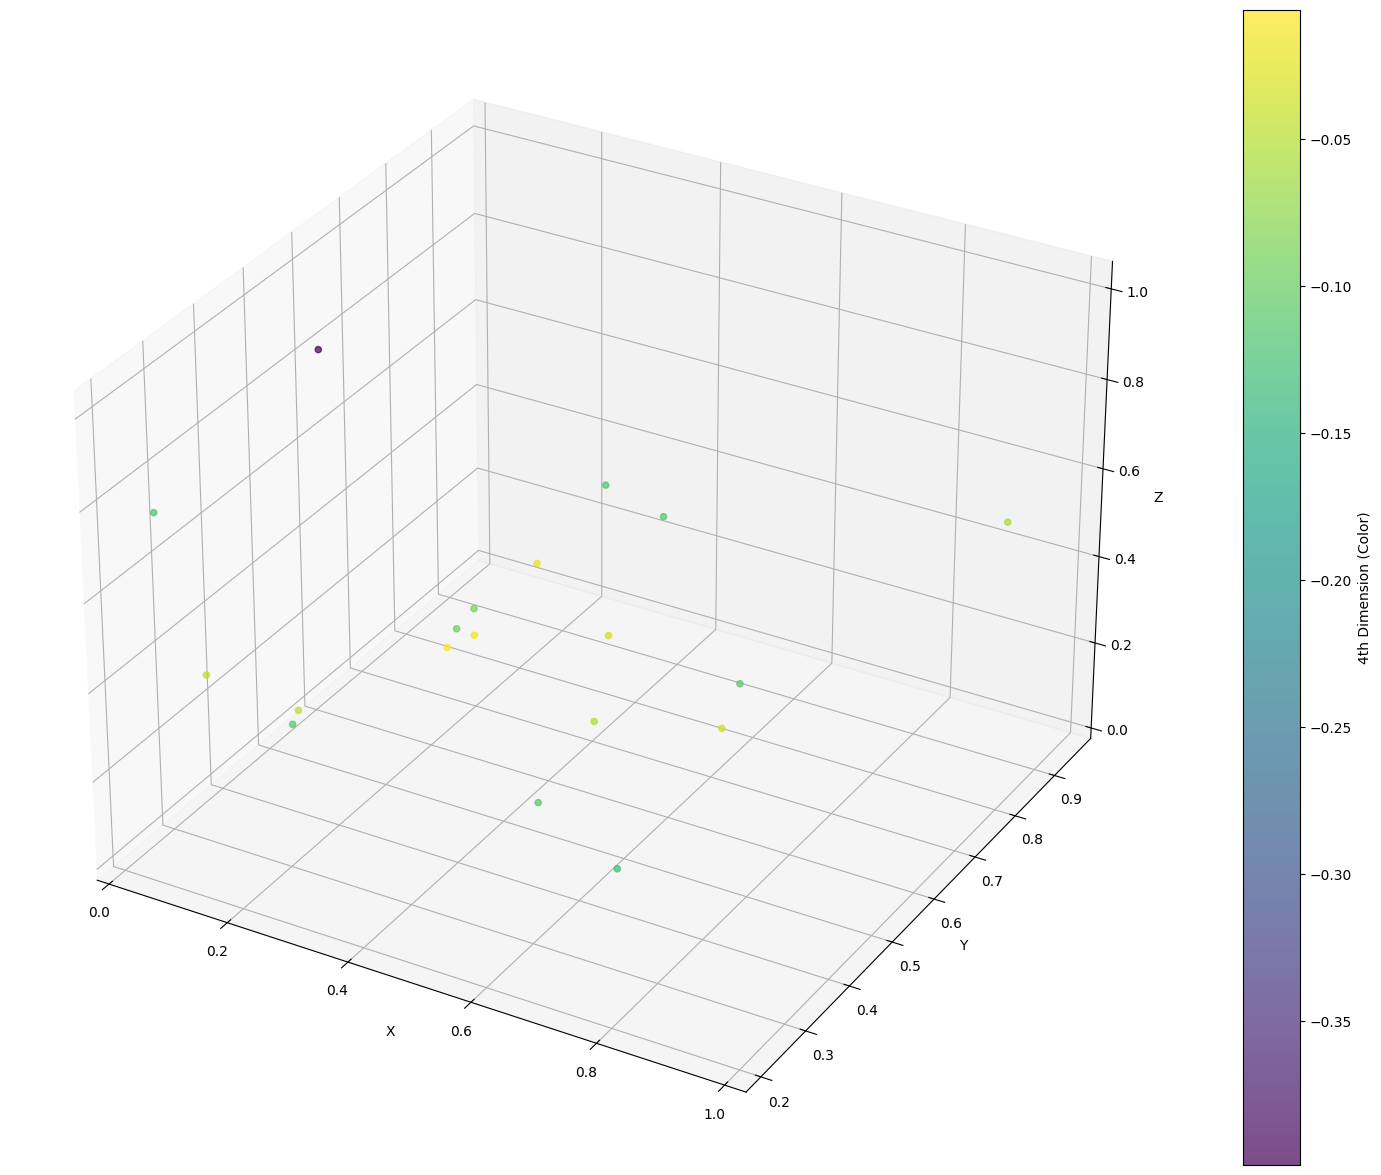

In [5]:
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', alpha=0.7)

fig.colorbar(sc, label='4th Dimension (Color)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

## Acquisition function - Bayesian Optimization - EI

In [6]:
# Expected Improvement acquisition function
def expected_improvement(X, gp, y_best, xi=0.01):
    mu, sigma = gp.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # avoid divide-by-zero
    
    Z = (mu - y_best - xi) / sigma
    ei = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0  # EI is zero where uncertainty is zero
    return ei

# Optimize acquisition globally (using Differential Evolution)

def optimize_acquisition_global(acquisition_func, gp, bounds, y_best, xi=0.01, maxiter=100, popsize=15):
    def objective1(x):
        x = np.array(x).reshape(1, -1)
        return -acquisition_func(x, gp=gp, y_best=y_best, xi=xi)[0]

    result = differential_evolution(
        objective1,
        bounds=bounds,
        maxiter=maxiter,
        popsize=popsize,
        polish=True,
        disp=True
    )

    x_next = result.x
    best_val = -result.fun
    return x_next, best_val    

In [7]:
bounds = [(0, 1), (0, 1), (0, 1)]

y_best = np.max(y)

next_point, best_val = optimize_acquisition_global(
        acquisition_func=expected_improvement,
        gp=gp,
        bounds=bounds,
        y_best=y_best,
        xi=0.01,     # increase xi for more exploration
        maxiter=8000,
        popsize=5000
    )

print("\nNext query point (by global EI):", next_point)
print("EI value at that point:", best_val)


differential_evolution step 1: f(x)= -0.012461093576588369
differential_evolution step 2: f(x)= -0.01249380839123579
differential_evolution step 3: f(x)= -0.01250867906448378
differential_evolution step 4: f(x)= -0.01250867906448378
differential_evolution step 5: f(x)= -0.01250867906448378
differential_evolution step 6: f(x)= -0.012511600735434527
differential_evolution step 7: f(x)= -0.012511600735434527
differential_evolution step 8: f(x)= -0.012511600735434527
differential_evolution step 9: f(x)= -0.012511600735434527
differential_evolution step 10: f(x)= -0.012511600735434527
differential_evolution step 11: f(x)= -0.0125116639931801
differential_evolution step 12: f(x)= -0.01251173580275654
differential_evolution step 13: f(x)= -0.01251173580275654
differential_evolution step 14: f(x)= -0.012511828413783704
differential_evolution step 15: f(x)= -0.012511828413783704
Polishing solution with 'L-BFGS-B'

Next query point (by global EI): [0.379012   0.12033238 0.4682381 ]
EI value at t

## Acquisition function - Bayesian Optimization - UCB

In [8]:
def hybrid_ucb(X, gp, kappa=4.0, alpha=0.5):

    mu, sigma = gp.predict(X, return_std=True)
    return alpha * mu + (1 - alpha) * (mu + kappa * sigma)


# ----------------------------------------------------
# 2. Global + local optimizer for the acquisition
# ----------------------------------------------------
def optimize_acquisition_global(acquisition_func, gp, bounds, n_random=5000, n_local=10, **kwargs):
    dim = len(bounds)

    # Step 1: Random exploration
    X_random = np.random.uniform(
        [b[0] for b in bounds],
        [b[1] for b in bounds],
        size=(n_random, dim)
    )
    y_random = acquisition_func(X_random, gp, **kwargs)

    # Step 2: Choose top n_local points for local refinement
    top_idx = np.argsort(y_random)[-n_local:]
    best_val = -np.inf
    best_x = None

    # Step 3: Local optimization (L-BFGS-B) from multiple starts
    for idx in top_idx:
        x0 = X_random[idx]

        def objective(x):
            return -acquisition_func(x.reshape(1, -1), gp, **kwargs)

        res = minimize(objective, x0=x0, bounds=bounds, method="L-BFGS-B")
        if not res.success:
            continue

        val = -res.fun
        if val > best_val:
            best_val = val
            best_x = res.x

    return best_x

In [14]:
bounds = [(0, 1), (0, 1), (0, 1)]

# Optimize acquisition
next_point1 = optimize_acquisition_global(hybrid_ucb, gp, bounds, n_random=10000, n_local=100, kappa=1, alpha=0.1)

# Transform back to [0, 1]^3

print("Next query point (by UCB):", next_point1)

Next query point (by UCB): [0.37213067 0.14420144 0.46904042]


## Predicte mean and standard deviation

In [11]:
x1 = np.linspace(0, 1, 20)
x2 = np.linspace(0, 1, 20)
x3 = np.linspace(0, 1, 20)
X1, X2, X3 = np.meshgrid(x1, x2, x3)
X_grid = np.column_stack([X1.ravel(), X2.ravel(),X3.ravel()])
y_mean, y_std = gp.predict(X_grid, return_std=True)

## Visualization - Predicted Mean

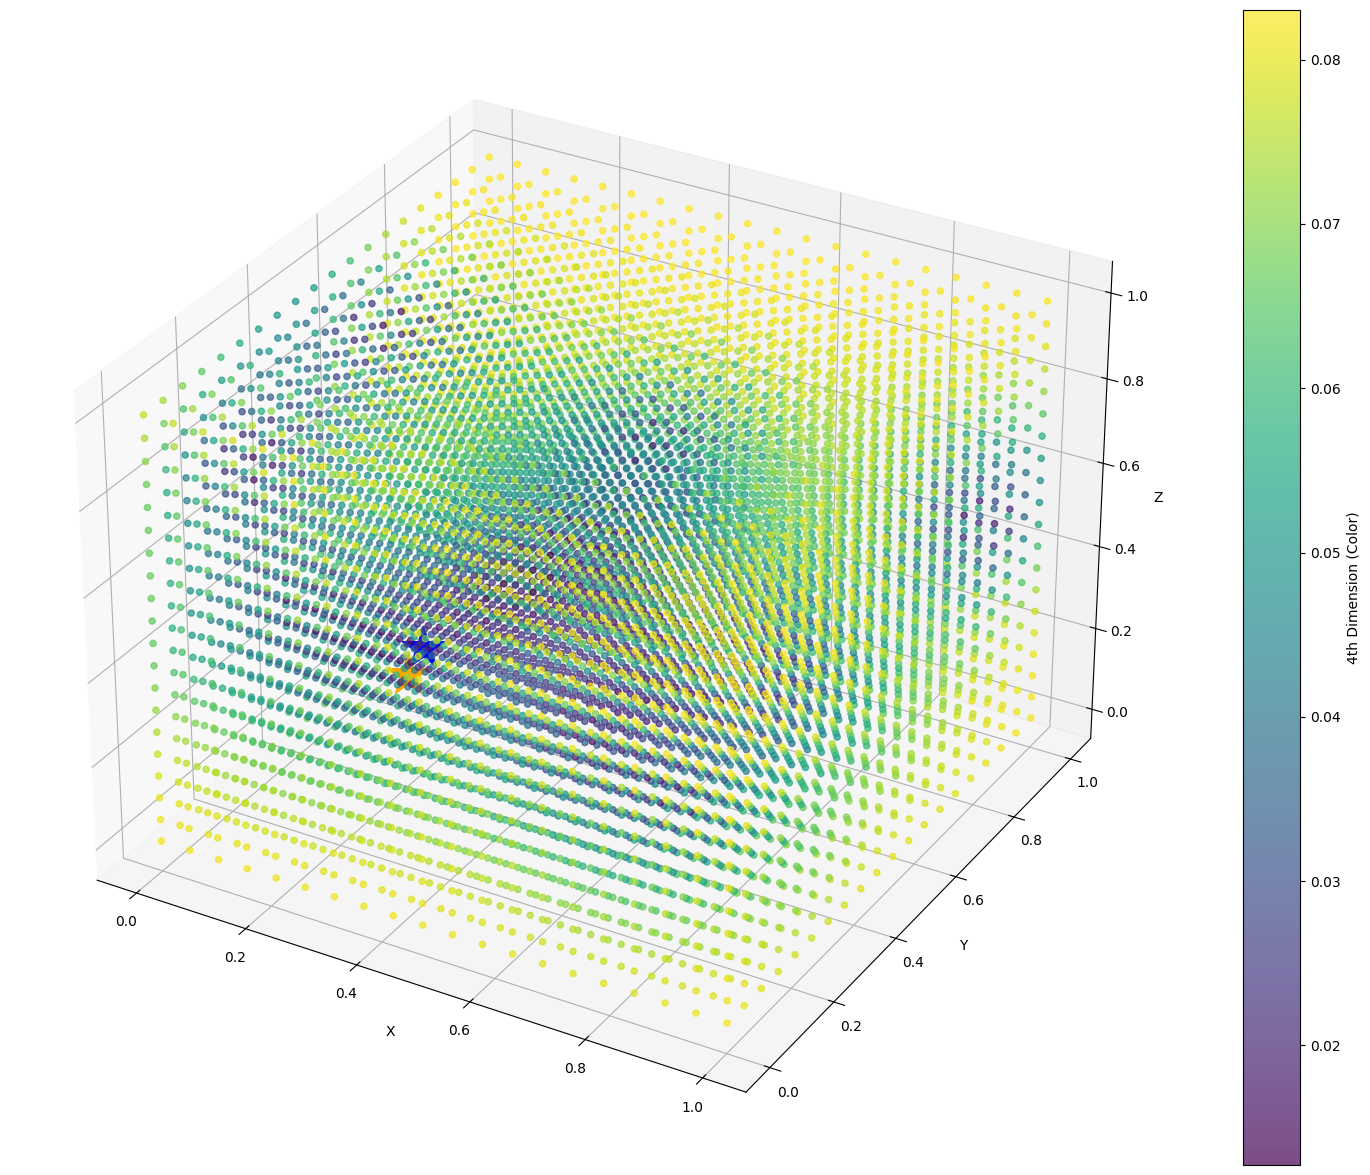

In [12]:
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_grid[:, 0], X_grid[:, 1], X_grid[:, 2], c= y_std, cmap='viridis', alpha=0.7)
ax.scatter(next_point[0], next_point[1], next_point[2], c="orange", s=1000, marker="*", label="Next query")
ax.scatter(next_point1[0], next_point1[1], next_point1[2], c="blue", s=1000, marker="*", label="Next query")

fig.colorbar(sc, label='4th Dimension (Color)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()